In [276]:
#code for Figure 3 panel E + F

In [318]:
library(dplyr)
library(lme4)
library(dplyr)
library(ggplot2)
library(ggpubr)
library(ggforce)

In [319]:
# Figure 3 

In [320]:
#import our telomere and sv merged data
merged_data <- read.delim(
  #"/home/mjehangir/telomere-sv-analysis/data/somatic_SV_CNV_TEL_merged_data.tsv",
      "/home/mjehangir/telomere-sv-analysis/data/aysa_SVs/aysa_somatic_SV_CNV_TEL_merged_data.tsv",

  sep = "\t", header = TRUE, stringsAsFactors = FALSE, check.names = FALSE
)

dim(merged_data)
head(merged_data)

[1] 1540   24

,filename,chr,Arm,arm_size.y,type,sv_count,sv_size_sum,chr_arm_length_mb,sv_rate,sv_proportion,⋯,final_average_TL_p75_kb,direction,TL_group,TL_kb,log_sv_rate,log_sv_prop,log_rate,has_sv,TL_scaled,arm_size_scaled
,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,2436A,chr1,p,124048267,BND,1,0.000000,124.04827,0.008061378,0.000000e+00,⋯,5.221000,Negative,Other,5.221000,-1.942610,-6.000000,-2.088236,1,0.09769090,1.3525406
2,2436A,chr1,p,124048267,DUP,2,0.032036,124.04827,0.016122756,2.582543e-04,⋯,5.221000,Negative,Other,5.221000,-1.710542,-3.586274,-1.789875,1,0.09769090,1.3525406
3,2436A,chr1,p,124048267,INS,4,0.000000,124.04827,0.032245513,0.000000e+00,⋯,5.221000,Negative,Other,5.221000,-1.448588,-6.000000,-1.490186,1,0.09769090,1.3525406
4,2436A,chr1,q,124339061,BND,2,0.000000,124.33906,0.016085050,0.000000e+00,⋯,5.051167,Negative,Other,5.051167,-1.711384,-6.000000,-1.790886,1,0.01152315,1.3606735
5,2436A,chr1,q,124339061,DEL,1,0.026438,124.33906,0.008042525,2.126283e-04,⋯,5.051167,Negative,Other,5.051167,-1.943328,-3.670341,-2.089241,1,0.01152315,1.3606735
6,2436A,chr10,p,40649191,DEL,1,0.003151,40.64919,0.024600736,7.751692e-05,⋯,3.611750,Negative,Other,3.611750,-1.553586,-4.105037,-1.607290,1,-0.71878869,-0.9799644


In [321]:
unique(merged_data$TL_group)
# To count how many unique samples there are
length(unique(merged_data$filename))

[1] "Other"    "Short TL"

[1] 20

In [322]:
head(merged_data)

,filename,chr,Arm,arm_size.y,type,sv_count,sv_size_sum,chr_arm_length_mb,sv_rate,sv_proportion,⋯,final_average_TL_p75_kb,direction,TL_group,TL_kb,log_sv_rate,log_sv_prop,log_rate,has_sv,TL_scaled,arm_size_scaled
,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,2436A,chr1,p,124048267,BND,1,0.000000,124.04827,0.008061378,0.000000e+00,⋯,5.221000,Negative,Other,5.221000,-1.942610,-6.000000,-2.088236,1,0.09769090,1.3525406
2,2436A,chr1,p,124048267,DUP,2,0.032036,124.04827,0.016122756,2.582543e-04,⋯,5.221000,Negative,Other,5.221000,-1.710542,-3.586274,-1.789875,1,0.09769090,1.3525406
3,2436A,chr1,p,124048267,INS,4,0.000000,124.04827,0.032245513,0.000000e+00,⋯,5.221000,Negative,Other,5.221000,-1.448588,-6.000000,-1.490186,1,0.09769090,1.3525406
4,2436A,chr1,q,124339061,BND,2,0.000000,124.33906,0.016085050,0.000000e+00,⋯,5.051167,Negative,Other,5.051167,-1.711384,-6.000000,-1.790886,1,0.01152315,1.3606735
5,2436A,chr1,q,124339061,DEL,1,0.026438,124.33906,0.008042525,2.126283e-04,⋯,5.051167,Negative,Other,5.051167,-1.943328,-3.670341,-2.089241,1,0.01152315,1.3606735
6,2436A,chr10,p,40649191,DEL,1,0.003151,40.64919,0.024600736,7.751692e-05,⋯,3.611750,Negative,Other,3.611750,-1.553586,-4.105037,-1.607290,1,-0.71878869,-0.9799644


In [323]:
unique(merged_data$TL_group)

[1] "Other"    "Short TL"

In [324]:
#Make sure if data is grouped per sample per arm for SV type
# --- 1. Organize the data by telomere group short vs other 
# Group by arm which have multiple BND or SV DEL 
df_clean <- merged_data %>%
  # Ensure numeric type
  mutate(
    sv_rate = as.numeric(as.character(sv_rate)),
    TL_group = factor(TL_group, levels = c("Other", "Short TL"))
  ) %>%
  # Group by: Sample + Chromosome + Arm + SV Type
  group_by(filename, chr, Arm, type, TL_group) %>%
  summarise(
    total_sv_rate = sum(sv_rate, na.rm = TRUE),
    .groups = "drop"
  )

In [325]:
nrow(merged_data)
nrow(df_clean)

[1] 1540

[1] 1540

In [326]:
colnames(df_clean)

[1] "filename"      "chr"           "Arm"           "type"         
[5] "TL_group"      "total_sv_rate"

In [327]:
colnames(merged_data)

[1] "filename"                "chr"                    
 [3] "Arm"                     "arm_size.y"             
 [5] "type"                    "sv_count"               
 [7] "sv_size_sum"             "chr_arm_length_mb"      
 [9] "sv_rate"                 "sv_proportion"          
[11] "region"                  "final_average_TL_p75"   
[13] "chr_order"               "arm"                    
[15] "final_average_TL_p75_kb" "direction"              
[17] "TL_group"                "TL_kb"                  
[19] "log_sv_rate"             "log_sv_prop"            
[21] "log_rate"                "has_sv"                 
[23] "TL_scaled"               "arm_size_scaled"

In [328]:
head(df_clean)

filename,chr,Arm,type,TL_group,total_sv_rate
<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>
2436A,chr1,p,BND,Other,0.008061378
2436A,chr1,p,DUP,Other,0.016122756
2436A,chr1,p,INS,Other,0.032245513
2436A,chr1,q,BND,Other,0.016085050
2436A,chr1,q,DEL,Other,0.008042525
2436A,chr10,p,DEL,Other,0.024600736


In [329]:
merged_data %>% select(filename, chr, Arm, type, TL_group, sv_rate) %>% head()

,filename,chr,Arm,type,TL_group,sv_rate
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,2436A,chr1,p,BND,Other,0.008061378
2,2436A,chr1,p,DUP,Other,0.016122756
3,2436A,chr1,p,INS,Other,0.032245513
4,2436A,chr1,q,BND,Other,0.016085050
5,2436A,chr1,q,DEL,Other,0.008042525
6,2436A,chr10,p,DEL,Other,0.024600736


In [330]:
# list of SV types present in data (BND, DEL, DUP, etc.)
types_to_plot <- unique(df_clean$type)

In [331]:
print(types_to_plot)

[1] "BND" "DUP" "INS" "DEL" "INV"


In [332]:
# --- 2. Function to plot the violin sina plots with comparison between  Short TL vs Other telomere groups---
#This will loop over each SV type for generating spearate panel of plot for each SV type


plot_list <- lapply(types_to_plot, function(t) {
  
  df_sub <- df_clean %>% filter(type == t)
  
  # Calculate N counts for labels 
  n_counts <- df_sub %>%
    group_by(TL_group) %>%
    summarise(n = n(), .groups = "drop")
  
  if(nrow(n_counts) < 2) return(NULL) # Skip if a group is missing
  
  # Wilcoxon Rank Sum Test
  wt_res <- wilcox.test(total_sv_rate ~ TL_group, data = df_sub)
  p_val <- format.pval(wt_res$p.value, digits = 2)
  
  # Create dynamic X-axis labels with n-counts
  x_labs <- setNames(paste0(n_counts$TL_group, "\n(n=", n_counts$n, ")"), n_counts$TL_group)

  # --- 3. THE PLOT ---
  p <- ggplot(df_sub, aes(x = TL_group, y = total_sv_rate, fill = TL_group)) +
    # Sina plot shows the true density and every individual arm
    geom_sina(aes(color = TL_group), alpha = 0.25, size = 1) +
    # Overlay narrow boxplot for summary stats
    geom_boxplot(width = 0.15, outlier.shape = NA, alpha = 0.7, color = "black", size = 0.6) +
    
    # Statistic for wilcox test in the plot
    stat_compare_means(method = "wilcox.test", label = "p.signif", 
                       label.x = 1.5, size = 5, vjust = 0.5) +
    
    scale_x_discrete(labels = x_labs) +
    scale_fill_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
    scale_color_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
    
    labs(
      #title = paste(t, "Events"),
      subtitle = paste0("Wilcoxon P: ", p_val),
      y = "SV rate (events/Mb)",
      x = NULL
    ) +
    theme_classic(base_size = 12) + 
    theme(
      legend.position = "none",
      plot.title = element_text(size = 12, face = "bold"),
      axis.text.x = element_text(size = 10, face = "bold", color = "black"),
      axis.title.y = element_text(size = 10)
    )
  
  return(p)
})

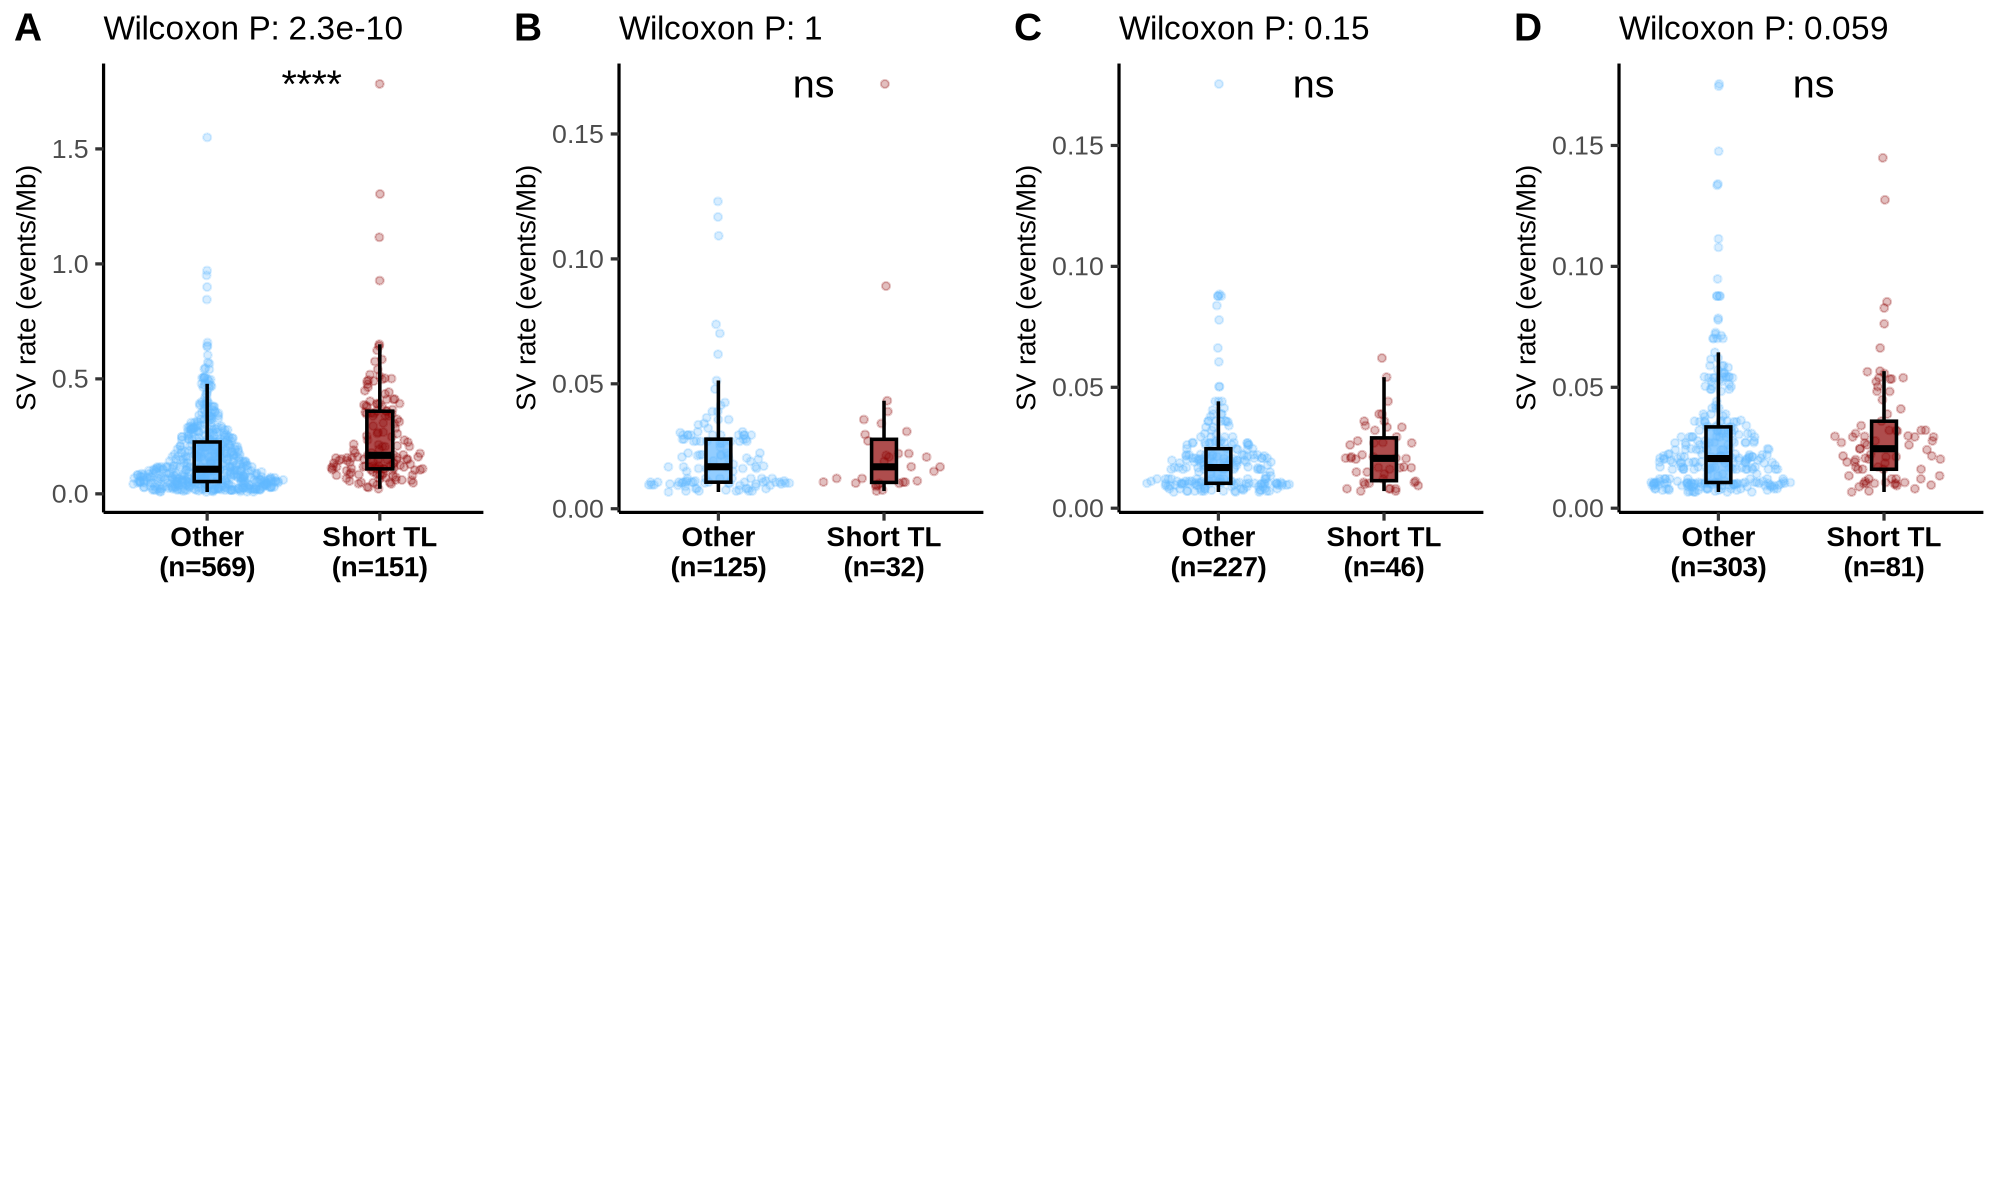

In [333]:
# Filter out empty plots if any and arrange
plot_list <- Filter(Negate(is.null), plot_list)
final_panel <- ggarrange(plotlist = plot_list, 
                         ncol = 4, 
                         nrow = ceiling(length(plot_list)/2),
                         labels = "AUTO") # Adds A, B, C labels auto

options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 200)

print(final_panel)

In [334]:
head(df_clean$type)

[1] "BND" "DUP" "INS" "BND" "DEL" "DEL"

In [335]:
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig3/new_sina_plot.pdf",
  plot = final_panel,
  width = 12,
  height = 8,
  units = "in"
)

In [336]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

In [337]:
# --- 1. extract subset of dataset for BND only ---
bnd_plot_data <- merged_data %>%
  filter(type == "BND", sv_rate > 0) %>%
  group_by(filename, chr, Arm) %>%
  summarise(
    total_sv_rate = sum(sv_rate, na.rm = TRUE),
    TL_group = factor(first(TL_group), levels = c("Other", "Short TL")),
    .groups = "drop"
  )

In [338]:
head(bnd_plot_data)

filename,chr,Arm,total_sv_rate,TL_group
<chr>,<chr>,<chr>,<dbl>,<fct>
2436A,chr1,p,0.008061378,Other
2436A,chr1,q,0.016085050,Other
2436A,chr10,q,0.106259827,Other
2436A,chr11,p,0.075838998,Other
2436A,chr11,q,0.012138212,Other
2436A,chr12,p,0.027846106,Other


In [298]:
merged_data %>% filter(type == "BND") %>%
select(filename, chr, Arm, sv_rate, TL_group) %>% head()

,filename,chr,Arm,sv_rate,TL_group
,<chr>,<chr>,<chr>,<dbl>,<chr>
1,2436A,chr1,p,0.008061378,Other
2,2436A,chr1,q,0.016085050,Other
3,2436A,chr10,q,0.106259827,Other
4,2436A,chr11,p,0.075838998,Other
5,2436A,chr11,q,0.012138212,Other
6,2436A,chr12,p,0.027846106,Other


In [299]:
merged_data %>% filter(type == "BND") %>% nrow()
nrow(bnd_plot_data)

[1] 720

[1] 720

In [300]:
# --- 2. CALCULATE STATISTICS & LABEL POSITIONS ---
# Find the count (n) and the highest point (y) for each group
label_data <- bnd_plot_data %>%
  group_by(TL_group) %>%
  summarise(
    n_count = paste0("n = ", n()),
    y_pos = max(total_sv_rate, na.rm = TRUE) * 1.1, # Place 10% above the highest dot
    .groups = "drop"
  )

# Wilcoxon Test
wt_res <- wilcox.test(total_sv_rate ~ TL_group, data = bnd_plot_data)
p_val <- format.pval(wt_res$p.value, digits = 3)

In [301]:
head(label_data)

TL_group,n_count,y_pos
<fct>,<chr>,<dbl>
Other,n = 569,1.705113
Short TL,n = 151,1.960757


In [302]:
unique(bnd_plot_data$TL_group)

[1] Other    Short TL
Levels: Other Short TL

In [303]:
head(bnd_plot_data)

filename,chr,Arm,total_sv_rate,TL_group
<chr>,<chr>,<chr>,<dbl>,<fct>
2436A,chr1,p,0.008061378,Other
2436A,chr1,q,0.016085050,Other
2436A,chr10,q,0.106259827,Other
2436A,chr11,p,0.075838998,Other
2436A,chr11,q,0.012138212,Other
2436A,chr12,p,0.027846106,Other


In [304]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)

bnd_z <- bnd_plot_data %>%
  mutate(TL_group = factor(TL_group, levels = c("Other", "Short TL"))) %>%
  group_by(filename) %>%
  mutate(
    patient_mean = mean(total_sv_rate, na.rm = TRUE),
    patient_sd   = sd(total_sv_rate, na.rm = TRUE),
    BND_z = if_else(patient_sd > 0,
                    (total_sv_rate - patient_mean) / patient_sd,
                    NA_real_)
  ) %>%
  ungroup()

In [305]:
head(bnd_z)

filename,chr,Arm,total_sv_rate,TL_group,patient_mean,patient_sd,BND_z
<chr>,<chr>,<chr>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>
2436A,chr1,p,0.008061378,Other,0.03320003,0.02476095,-1.0152540
2436A,chr1,q,0.016085050,Other,0.03320003,0.02476095,-0.6912086
2436A,chr10,q,0.106259827,Other,0.03320003,0.02476095,2.9506054
2436A,chr11,p,0.075838998,Other,0.03320003,0.02476095,1.7220246
2436A,chr11,q,0.012138212,Other,0.03320003,0.02476095,-0.8506063
2436A,chr12,p,0.027846106,Other,0.03320003,0.02476095,-0.2162246


In [306]:
unique(bnd_z$patient_mean)

[1] 0.03320003 0.37099439 0.30758227 0.10869353 0.05272567 0.12708109
 [7] 0.07838663 0.10720617 0.06604776 0.20661053 0.24727714 0.08431639
[13] 0.41293481 0.05700254 0.17930692 0.10962284 0.20861040 0.09664657
[19] 0.45469568 0.14947184

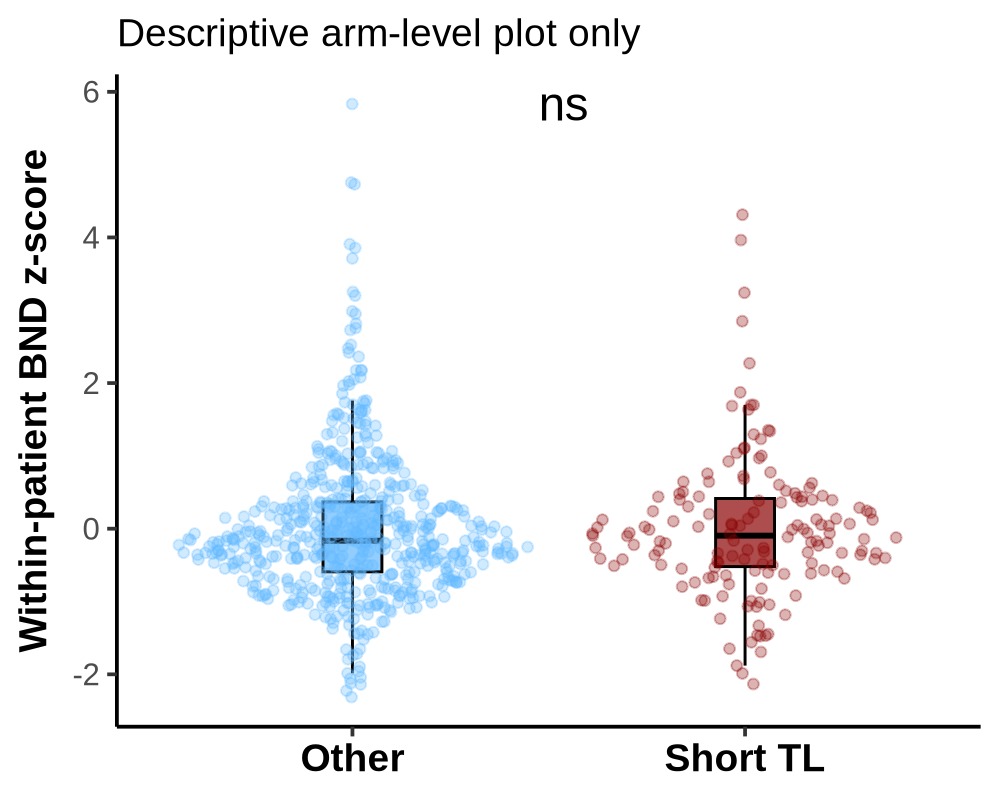

In [307]:
ggplot(bnd_z, aes(x = TL_group, y = BND_z, fill = TL_group)) +
  geom_boxplot(width = 0.15, outlier.shape = NA, alpha = 0.7, color = "black") +
  geom_sina(aes(color = TL_group), alpha = 0.3, size = 1.5) +
  scale_fill_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
  scale_color_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
  labs(
    y = "Within-patient BND z-score",
    x = NULL,
    subtitle = "Descriptive arm-level plot only"
  ) +
  theme_classic(base_size = 14) +
  theme(
    legend.position = "none",
    axis.text.x = element_text(face = "bold", size = 14, color = "black"),
    axis.title.y = element_text(face = "bold")
  ) +
  # Significance Bracket
  stat_compare_means(method = "t.test", label = "p.signif", 
                     label.x = 1.5, size = 6, vjust = 0.5)

In [308]:
patient_bnd <- bnd_plot_data %>%
  group_by(filename, TL_group) %>%
  summarise(mean_BND = sum(total_sv_rate, na.rm = TRUE), .groups = "drop")

wilcox.test(mean_BND ~ TL_group, data = patient_bnd)


	Wilcoxon rank sum exact test

data:  mean_BND by TL_group
W = 16, p-value = 0.1482
alternative hypothesis: true location shift is not equal to 0


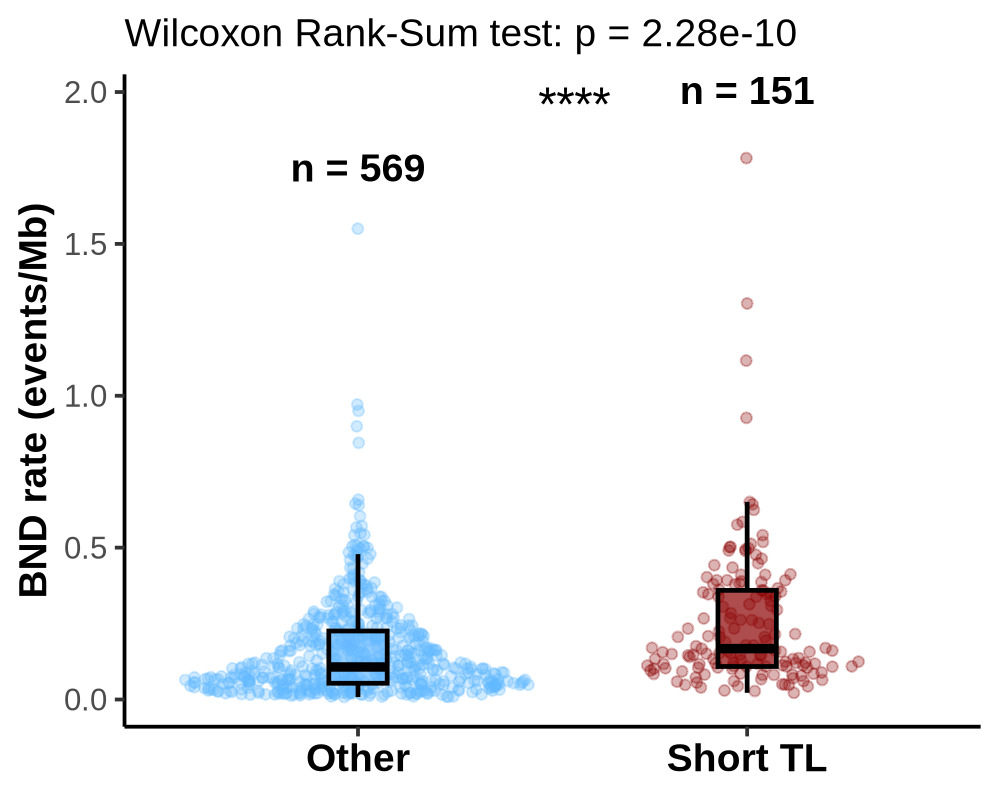

In [311]:
# --- 3. THE PLOT ---
ggplot(bnd_plot_data, aes(x = TL_group, y = total_sv_rate, fill = TL_group)) +
  # Sina plot (Nature style density)
  geom_sina(aes(color = TL_group), alpha = 0.3, size = 1.5) +
  
  # Professional thin boxplot
  geom_boxplot(width = 0.15, outlier.shape = NA, alpha = 0.7, color = "black", size = 0.8) +
  
  # ADD N-LABELS ABOVE SINA
  geom_text(data = label_data, aes(x = TL_group, y = y_pos, label = n_count), 
            vjust = 0, size = 5, fontface = "bold", inherit.aes = FALSE) +
  
  # Significance Bracket
  stat_compare_means(method = "wilcox.test", label = "p.signif", 
                     label.x = 1.5, size = 6, vjust = 0.5) +
  
  # Styling
  scale_fill_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
  scale_color_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
  
  labs(
    #title = "BND vent Magnitude",
    subtitle = paste0("Wilcoxon Rank-Sum test: p = ", p_val),
    y = "BND rate (events/Mb)",
    x = NULL
  ) +
  theme_classic(base_size = 14) +
  theme(
    legend.position = "none",
    plot.title = element_text(face = "bold", size = 18),
    axis.text.x = element_text(face = "bold", size = 14, color = "black"),
    axis.title.y = element_text(face = "bold")
  )

In [75]:
151 + 569
nrow(bnd_plot_data)

[1] 720

[1] 720

In [76]:
#Now for pairwise correlation plot

# Filter for BND data
bnd_data <- merged_data %>% 
  filter(type == "BND")

In [77]:
nrow(bnd_data)

[1] 720

In [78]:
unique(bnd_data$type)

[1] "BND"

`geom_smooth()` using formula = 'y ~ x'


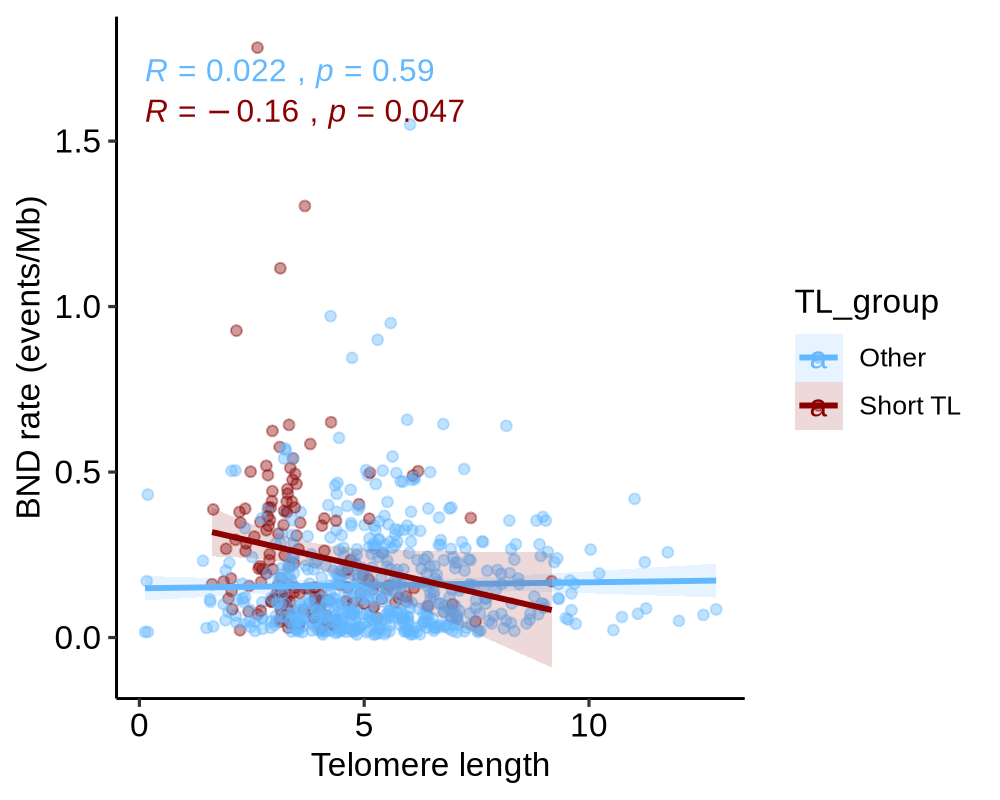

In [79]:
# Correlation plot with telomere group wise correlation

p <- ggplot(bnd_data, aes(x = final_average_TL_p75_kb, y = sv_rate, color = TL_group, fill = TL_group)) +
  geom_point(alpha = 0.4, size = 1.5) +
  geom_smooth(method = "lm", se = TRUE, alpha = 0.15) +
  # Pearson correlation
stat_cor(method = "pearson",
         aes(label = paste(..r.label.., ..p.label.., sep = "~`,`~")),
         label.x.npc = "left", label.y.npc = "top", size = 4) +
  
  scale_color_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
  scale_fill_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
  labs(
    x = "Telomere length",
    y = "BND rate (events/Mb)"
  ) +
  theme_pubr() +
  theme(legend.position = "right")
options(repr.plot.width = 5, repr.plot.height = 4)  # reset if needed

print(p)

In [81]:
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig3/new_correlation_plot.pdf",
  plot = p,
  width = 5,
  height = 4,
  units = "in"
)

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


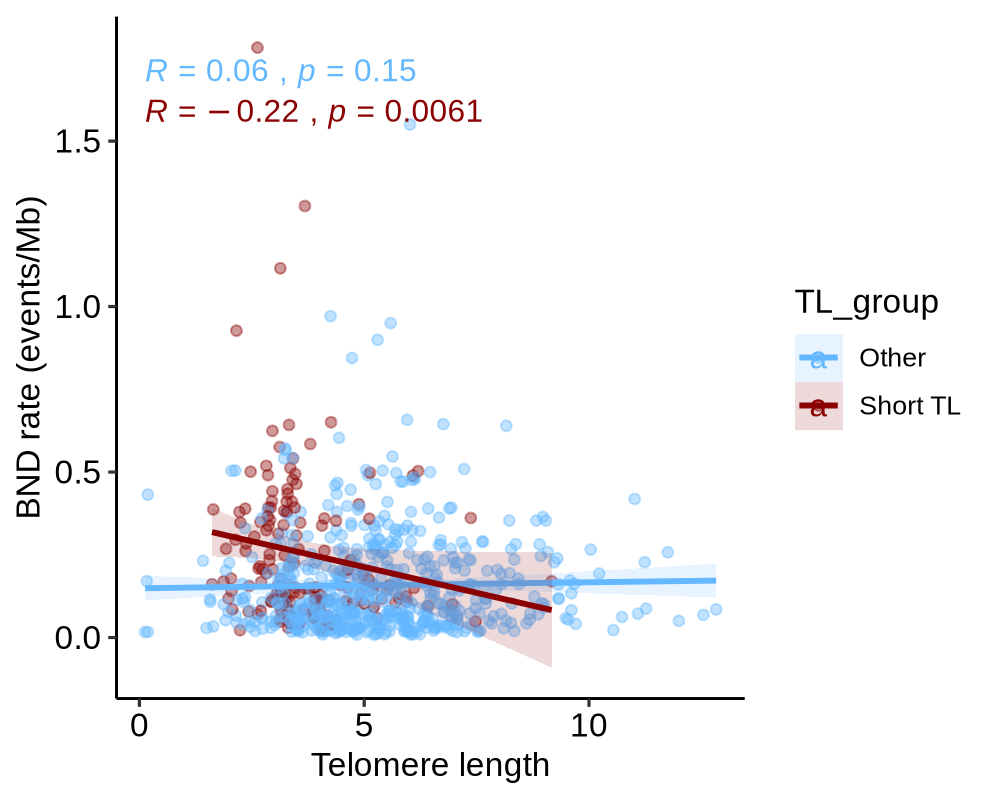

In [82]:
# Spearman Correlation plot with telomere group wise correlation

p <- ggplot(bnd_data, aes(x = final_average_TL_p75_kb, y = sv_rate, color = TL_group, fill = TL_group)) +
  geom_point(alpha = 0.4, size = 1.5) +
  geom_smooth(method = "lm", se = TRUE, alpha = 0.15) +
  # Pearson correlation
stat_cor(method = "spearman",
         aes(label = paste(..r.label.., ..p.label.., sep = "~`,`~")),
         label.x.npc = "left", label.y.npc = "top", size = 4) +
  
  scale_color_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
  scale_fill_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
  labs(
    x = "Telomere length",
    y = "BND rate (events/Mb)"
  ) +
  theme_pubr() +
  theme(legend.position = "right")
options(repr.plot.width = 5, repr.plot.height = 4)  # reset if needed

print(p)